<a href="https://colab.research.google.com/github/GabrielaRguezCampos/other/blob/main/Workshop5_MonkeyData.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
file_path = "/content/Workshop5_MonkeyData_To_use.csv"
df = pd.read_csv(file_path)

In [ ]:
# Looking at the data structure
print("Data shape:", df.shape)
print("\nFirst few rows:")
print(df.head())


Data shape: (27, 12)

First few rows:
   Monkey #  2 Eyes Open  1 Eye Open  X Eyes  Teeth Shown  Mouth Open  \
0         1            1           0       0            1           0   
1         2            0           1       0            1           0   
2         4            0           0       0            1           0   
3         5            1           0       0            0           0   
4         7            0           0       1            0           0   

   Tongue Out  Glasses  Spiky Hair  Band Aid  Hair Bow  Biting  
0           0        0         0.0         0         0       1  
1           0        0         0.0         0         0       1  
2           0        0         0.0         0         0       0  
3           0        0         0.0         0         0       1  
4           0        0         0.0         0         0       0  


In [ ]:
# Separate features and target
feature_cols = df.columns[1:-1]  # Exclude Monkey # and Biting
features_df = df[feature_cols]
target = df['Biting']


In [ ]:
# Print the feature columns to verify
print("\nFeature columns:")
print(feature_cols.tolist())
print("\nTarget column: Biting")


Feature columns:
['2 Eyes Open', '1 Eye Open', 'X Eyes', 'Teeth Shown', 'Mouth Open', 'Tongue Out', 'Glasses', 'Spiky Hair', 'Band Aid', 'Hair Bow']

Target column: Biting


In [ ]:
# Calculate the covariance matrix of features
cov_matrix = features_df.cov()
print("\nCovariance Matrix of Features:")
print(cov_matrix)


Covariance Matrix of Features:
             2 Eyes Open  1 Eye Open    X Eyes  Teeth Shown  Mouth Open  \
2 Eyes Open     0.216524   -0.068376 -0.056980    -0.029915   -0.029915   
1 Eye Open     -0.068376    0.179487 -0.042735     0.025641   -0.012821   
X Eyes         -0.056980   -0.042735  0.156695    -0.004274    0.034188   
Teeth Shown    -0.029915    0.025641 -0.004274     0.179487   -0.051282   
Mouth Open     -0.029915   -0.012821  0.034188    -0.051282    0.179487   
Tongue Out      0.008547   -0.012821 -0.004274    -0.051282   -0.051282   
Glasses         0.019943    0.034188 -0.035613    -0.004274   -0.004274   
Spiky Hair     -0.021538   -0.046154  0.009231     0.001538   -0.006154   
Band Aid       -0.022792   -0.017094  0.024217     0.021368   -0.017094   
Hair Bow       -0.022792    0.021368 -0.014245    -0.017094    0.021368   

             Tongue Out   Glasses  Spiky Hair  Band Aid  Hair Bow  
2 Eyes Open    0.008547  0.019943   -0.021538 -0.022792 -0.022792  
1 Eye 

In [ ]:
# Calculate the correlation matrix of features
corr_matrix = features_df.corr()
print("\nCorrelation Matrix of Features:")
print(corr_matrix)


Correlation Matrix of Features:
             2 Eyes Open  1 Eye Open    X Eyes  Teeth Shown  Mouth Open  \
2 Eyes Open     1.000000   -0.346844 -0.309344    -0.151744   -0.151744   
1 Eye Open     -0.346844    1.000000 -0.254824     0.142857   -0.071429   
X Eyes         -0.309344   -0.254824  1.000000    -0.025482    0.203859   
Teeth Shown    -0.151744    0.142857 -0.025482     1.000000   -0.285714   
Mouth Open     -0.151744   -0.071429  0.203859    -0.285714    1.000000   
Tongue Out      0.043355   -0.071429 -0.025482    -0.285714   -0.285714   
Glasses         0.108270    0.203859 -0.227273    -0.025482   -0.025482   
Spiky Hair     -0.113855   -0.267261  0.062419     0.009524   -0.035635   
Band Aid       -0.183533   -0.151186  0.229228     0.188982   -0.151186   
Hair Bow       -0.183533    0.188982 -0.134840    -0.151186    0.188982   

             Tongue Out   Glasses  Spiky Hair  Band Aid  Hair Bow  
2 Eyes Open    0.043355  0.108270   -0.113855 -0.183533 -0.183533  
1 Eye

In [ ]:
# Calculate correlation of features with the target (Biting)
corr_with_target = pd.DataFrame()
for col in feature_cols:
    corr_with_target.loc[col, 'Correlation with Biting'] = df[col].corr(target)

print("\nCorrelation of each feature with Biting:")
print(corr_with_target.sort_values('Correlation with Biting', ascending=False))


Correlation of each feature with Biting:
             Correlation with Biting
Mouth Open                  0.554700
2 Eyes Open                 0.348715
1 Eye Open                  0.019811
Hair Bow                    0.010483
X Eyes                     -0.077743
Spiky Hair                 -0.097590
Teeth Shown                -0.158486
Glasses                    -0.268566
Band Aid                   -0.272554
Tongue Out                 -0.336782


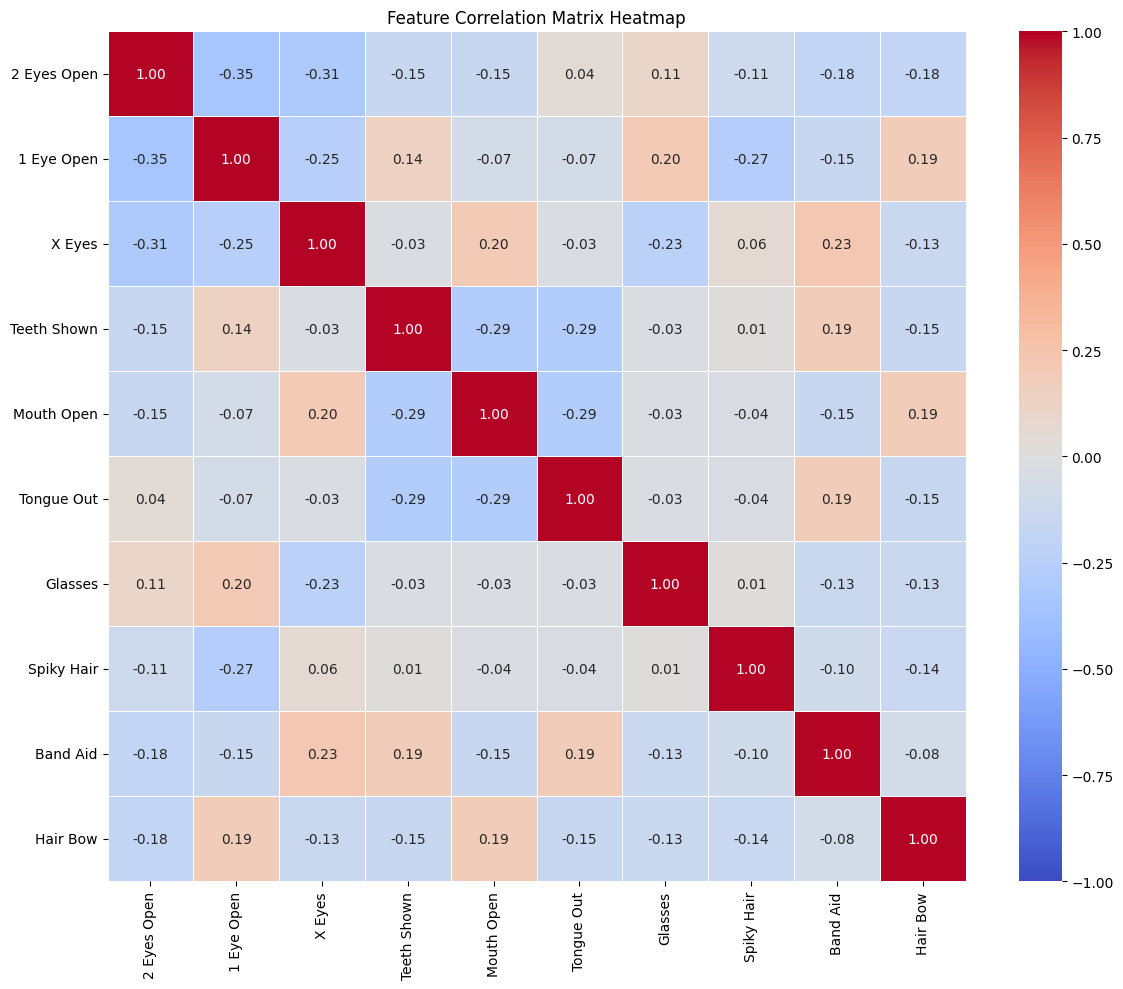

In [ ]:
# Visualize the correlation matrix of features
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=0.5, fmt=".2f")
plt.title("Feature Correlation Matrix Heatmap")
plt.tight_layout()
# plt.savefig("monkey_feature_correlation_heatmap.png")

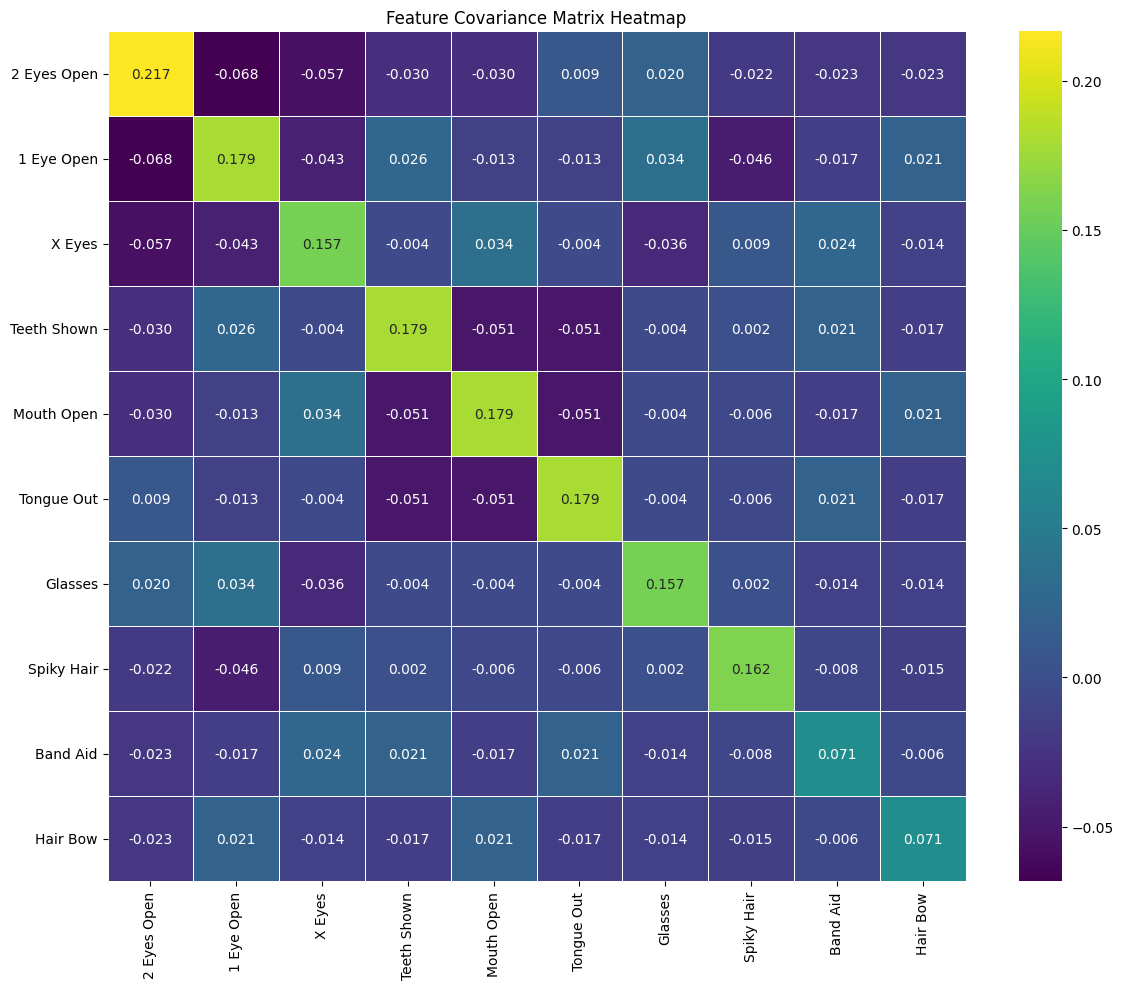

In [ ]:
# Visualize the covariance matrix of features
plt.figure(figsize=(12, 10))
sns.heatmap(cov_matrix, annot=True, cmap='viridis',
            linewidths=0.5, fmt=".3f")
plt.title("Feature Covariance Matrix Heatmap")
plt.tight_layout()
# plt.savefig("monkey_feature_covariance_heatmap.png")

<Figure size 1000x600 with 0 Axes>

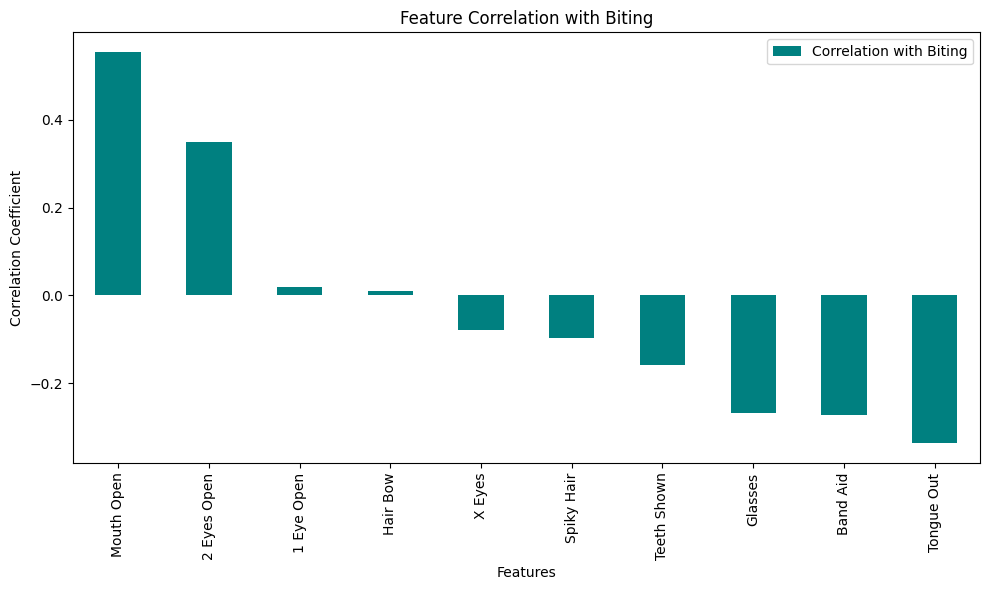

In [ ]:
# Visualize correlation with target
plt.figure(figsize=(10, 6))
corr_with_target.sort_values('Correlation with Biting', ascending=False).plot(
    kind='bar', color='teal', figsize=(10, 6))
plt.title('Feature Correlation with Biting')
plt.xlabel('Features')
plt.ylabel('Correlation Coefficient')
plt.tight_layout()
# plt.savefig("correlation_with_biting.png")

Data shape: (27, 12)

First few rows:
   Monkey #  2 Eyes Open  1 Eye Open  X Eyes  Teeth Shown  Mouth Open  \
0         1            1           0       0            1           0   
1         2            0           1       0            1           0   
2         4            0           0       0            1           0   
3         5            1           0       0            0           0   
4         7            0           0       1            0           0   

   Tongue Out  Glasses  Spiky Hair  Band Aid  Hair Bow  Biting  
0           0        0         0.0         0         0       1  
1           0        0         0.0         0         0       1  
2           0        0         0.0         0         0       0  
3           0        0         0.0         0         0       1  
4           0        0         0.0         0         0       0  

Feature columns:
['2 Eyes Open', '1 Eye Open', 'X Eyes', 'Teeth Shown', 'Mouth Open', 'Tongue Out', 'Glasses', 'Spiky Hair', 'Band A

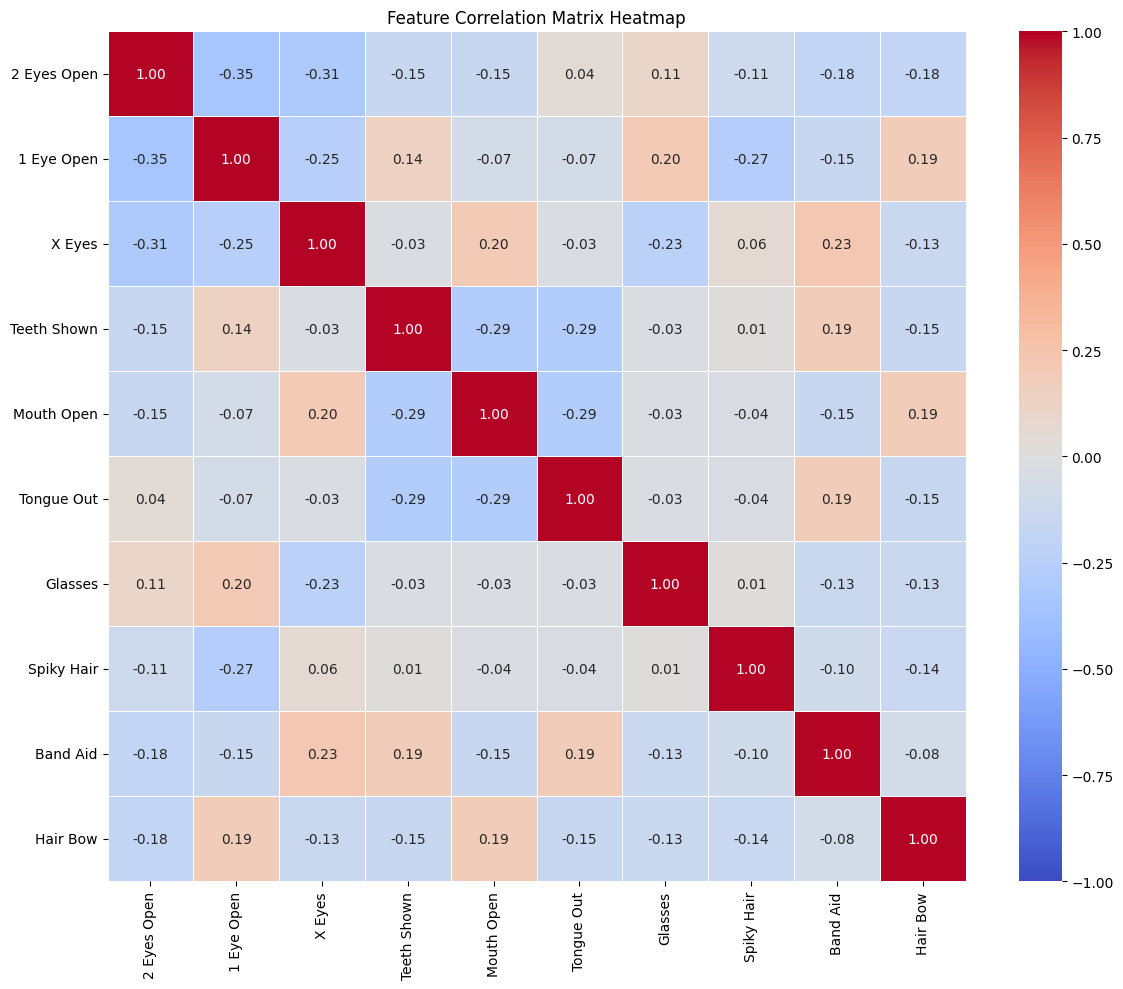

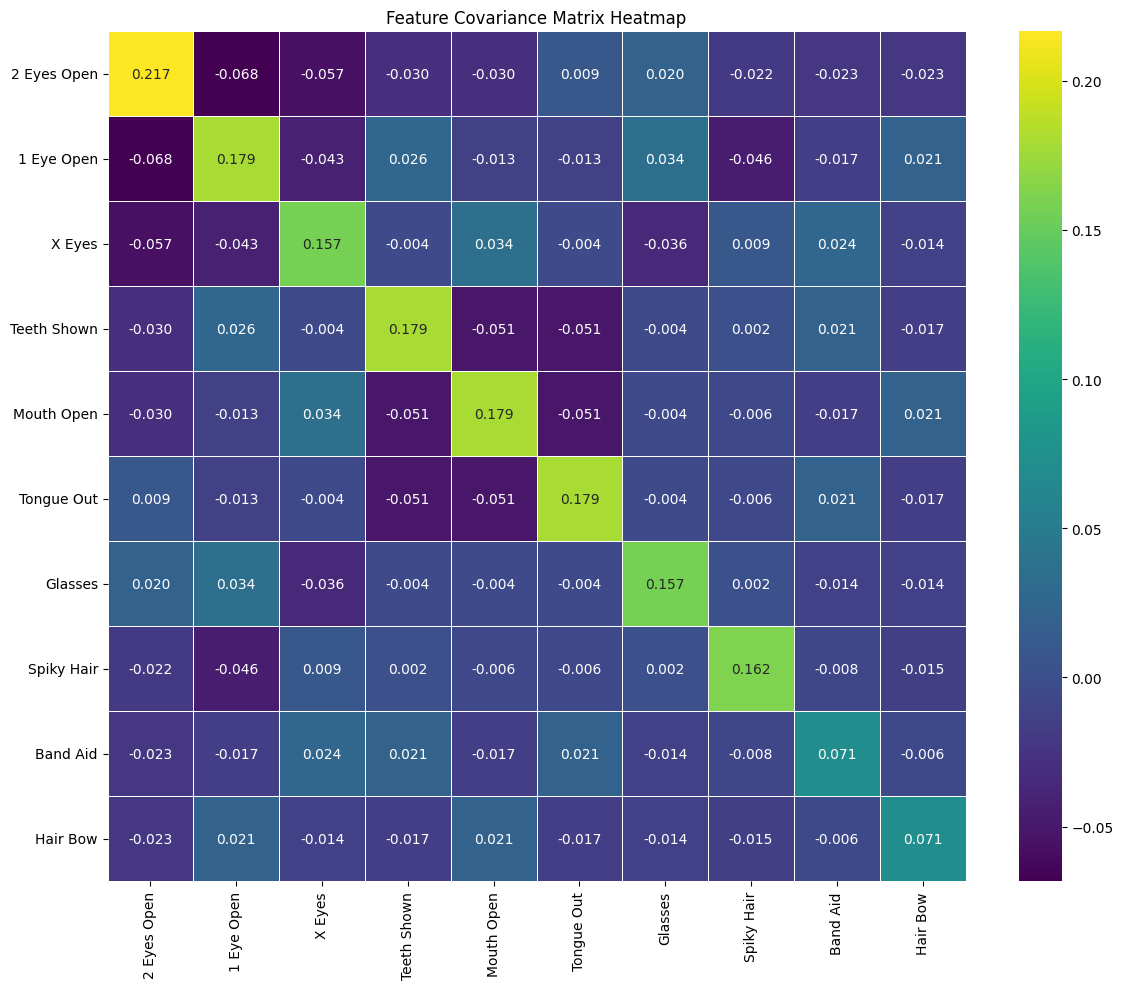

<Figure size 1000x600 with 0 Axes>

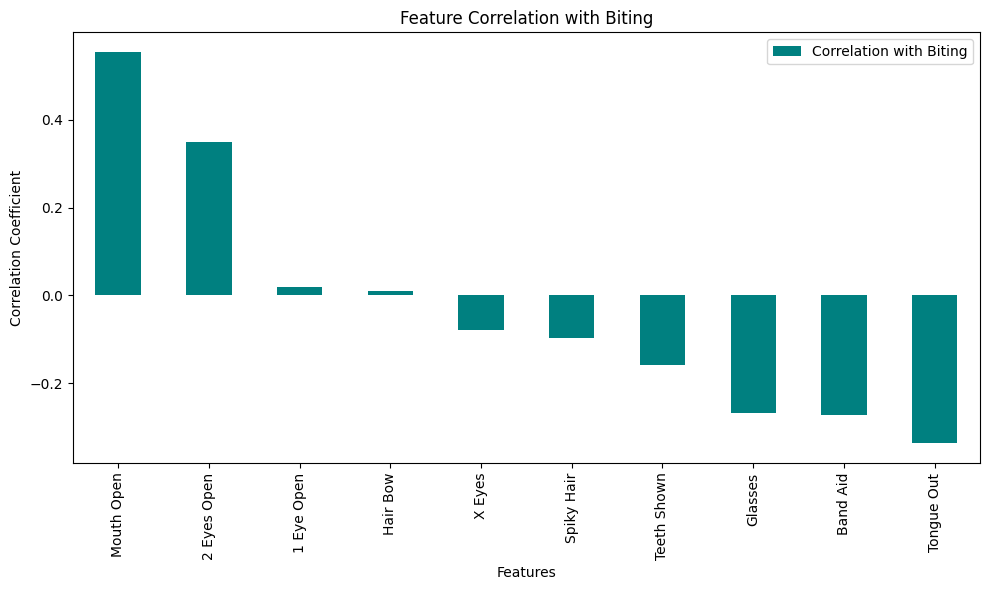

In [ ]:

# Save the matrices to CSV files
# cov_matrix.to_csv("monkey_feature_covariance_matrix.csv")
# corr_matrix.to_csv("monkey_feature_correlation_matrix.csv")
# corr_with_target.to_csv("correlation_with_biting.csv")

print("\nAnalysis complete. Matrices saved to CSV files and heatmaps saved as PNG files.")